In [2]:
import pandas as pd 
import numpy as np

In [3]:
dataset=pd.read_csv("SMSSpamCollection",sep='\t',names=['label','message'])

In [4]:
dataset

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
dataset.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [7]:
dataset.isnull().sum()

label      0
message    0
dtype: int64

In [11]:
dataset['label']=dataset['label'].map({'ham':0,'spam':1})

In [12]:
dataset

,label,message,contains_number
0,0,"Go until jurong point, crazy.. Available only ...",0
1,0,Ok lar... Joking wif u oni...,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,0,U dun say so early hor... U c already then say...,0
4,0,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,1
5568,0,Will ü b going to esplanade fr home?,0
5569,0,"Pity, * was in mood for that. So...any other s...",0
5570,0,The guy did some bitching but I acted like i'd...,0


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

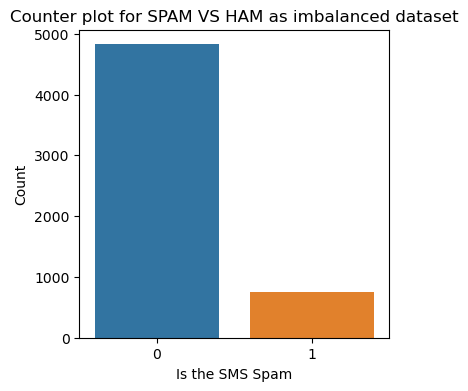

In [14]:
plt.figure(figsize=(4,4))
g=sns.countplot(x="label",data=dataset )
p=plt.title("Counter plot for SPAM VS HAM as imbalanced dataset")
p=plt.xlabel('Is the SMS Spam')
p=plt.ylabel('Count')

In [15]:
# handling imbalanced dataset using oversampling

In [16]:
only_spam = dataset[dataset["label"] == 1]

In [17]:
only_spam

,label,message,contains_number
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,1
5,1,FreeMsg Hey there darling it's been 3 week's n...,1
8,1,WINNER!! As a valued network customer you have...,1
9,1,Had your mobile 11 months or more? U R entitle...,1
11,1,"SIX chances to win CASH! From 100 to 20,000 po...",1
...,...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...,1
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1
5547,1,Had your contract mobile 11 Mnths? Latest Moto...,1
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...,1


In [18]:
print("No of Spam SMS : ",len(only_spam))
print("No of Ham SMS : ",len(dataset) - len(only_spam))

No of Spam SMS :  747
No of Ham SMS :  4825


In [19]:
# Here to add 

In [20]:
count=int((dataset.shape[0]-only_spam.shape[0])/only_spam.shape[0])

In [21]:
count

6

In [22]:
for i in range(0,count-1):
    dataset = pd.concat([dataset,only_spam])
dataset.shape

(9307, 3)

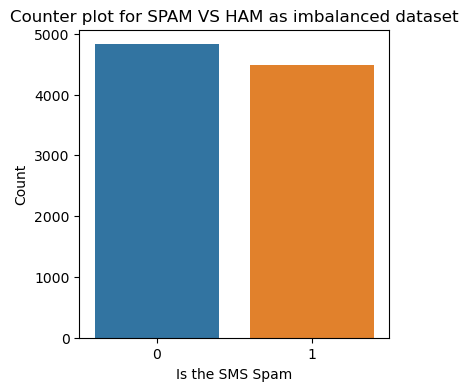

In [23]:
plt.figure(figsize=(4,4))
g=sns.countplot(x="label",data=dataset )
p=plt.title("Counter plot for SPAM VS HAM as imbalanced dataset")
p=plt.xlabel('Is the SMS Spam')
p=plt.ylabel('Count')

In [24]:
#creating new features

In [25]:
dataset['word_count']= dataset['message'].apply(lambda x:len(x.split()))

In [26]:
dataset

,label,message,contains_number,word_count
0,0,"Go until jurong point, crazy.. Available only ...",0,20
1,0,Ok lar... Joking wif u oni...,0,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,1,28
3,0,U dun say so early hor... U c already then say...,0,11
4,0,"Nah I don't think he goes to usf, he lives aro...",0,13
...,...,...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...,1,16
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1,33
5547,1,Had your contract mobile 11 Mnths? Latest Moto...,1,28
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...,1,28


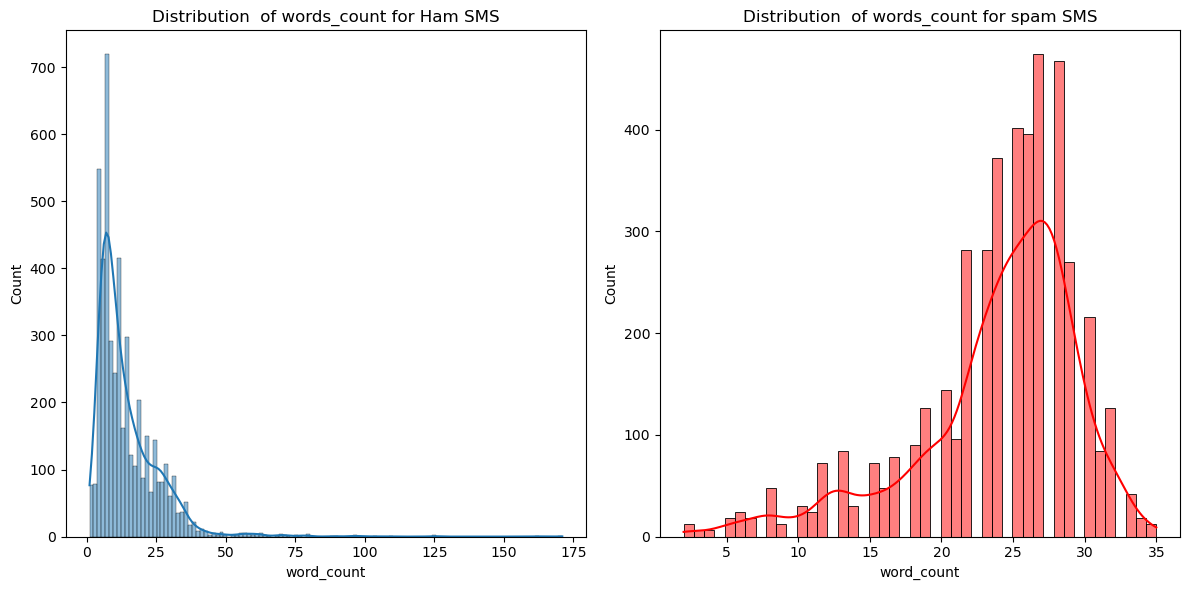

In [27]:
plt.figure(figsize=(12,6))

#(1,1) 
plt.subplot(1,2,1)
g=sns.histplot(dataset[dataset['label']==0].word_count,kde=True)
p=plt.title('Distribution  of words_count for Ham SMS')

#(1,2)
plt.subplot(1,2,2)
g=sns.histplot(dataset[dataset['label']==1].word_count,color='red',kde=True)
p=plt.title('Distribution  of words_count for spam SMS')

plt.tight_layout()
plt.show()

In [28]:
#Creating the new feature of containg currency symbol

In [29]:
def currency_present(data):
    currency_symbol=['$','₹','¥','€','£']
    for i in currency_symbol:
        if i in dataset:
            return 1
        return 0

In [30]:
dataset["contains_currency_synbols"]=dataset["message"].apply(currency_present)

In [31]:
dataset

,label,message,contains_number,word_count,contains_currency_synbols
0,0,"Go until jurong point, crazy.. Available only ...",0,20,0
1,0,Ok lar... Joking wif u oni...,0,6,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,1,28,0
3,0,U dun say so early hor... U c already then say...,0,11,0
4,0,"Nah I don't think he goes to usf, he lives aro...",0,13,0
...,...,...,...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...,1,16,0
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1,33,0
5547,1,Had your contract mobile 11 Mnths? Latest Moto...,1,28,0
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...,1,28,0


In [32]:
#creating the count plot for contain_currency_symbols

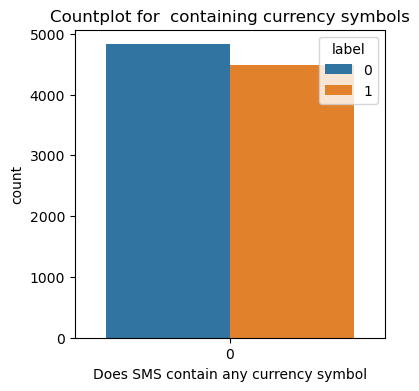

In [33]:
plt.figure(figsize=(4,4))
g=sns.countplot(x="contains_currency_synbols",data=dataset,hue="label")
p=plt.title("Countplot for  containing currency symbols")
p=plt.xlabel("Does SMS contain any currency symbol")
p=plt.ylabel("count")


In [34]:
def number(data):
    for i in data:
        if ord(i) >=48 and ord(i)<= 57:
            return 1
    return 0

In [35]:
dataset["contains_number"]=dataset["message"].apply(number)

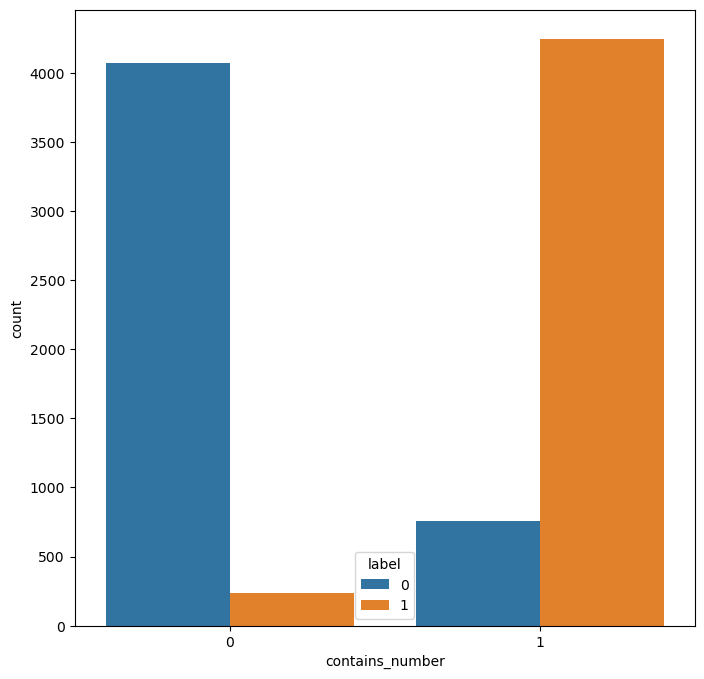

In [36]:
plt.figure(figsize=(8,8))
p=sns.countplot(x="contains_number",data=dataset,hue="label")

In [43]:
#Data cleaning 
import nltk
import re
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prasa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\prasa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [46]:
corpus = []
wnl = WordNetLemmatizer()

for sms in list(dataset.message):
    message=re.sub(pattern='[^a-zA-Z]',repl = ' ',string=sms)    #fitering out special charecter
    message=message.lower()
    words=message.split()
    filtered_words=[word for word in words if word not in set(stopwords.words('english'))]
    lemm_words=[wnl.lemmatize(word) for word in filtered_words]
    message=' '.join(lemm_words)
    
    corpus.append(message)
    

In [47]:
corpus

['go jurong point crazy available bugis n great world la e buffet cine got amore wat',
 'ok lar joking wif u oni',
 'free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply',
 'u dun say early hor u c already say',
 'nah think go usf life around though',
 'freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv',
 'even brother like speak treat like aid patent',
 'per request melle melle oru minnaminunginte nurungu vettam set callertune caller press copy friend callertune',
 'winner valued network customer selected receivea prize reward claim call claim code kl valid hour',
 'mobile month u r entitled update latest colour mobile camera free call mobile update co free',
 'gonna home soon want talk stuff anymore tonight k cried enough today',
 'six chance win cash pound txt csh send cost p day day tsandcs apply reply hl info',
 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd pobox ldnw rw'

In [54]:
# Creating the Bag of words model
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=500)
vectors = tfidf.fit_transform(corpus).toarray()
feature_names=tfidf.get_feature_names_out()

In [55]:
X=pd.DataFrame(vectors,columns=feature_names)
y=dataset['label']

In [62]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

In [63]:
X_train,X_test,y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [64]:
X_test

,ac,access,account,address,admirer,age,already,also,always,amp,...,xxx,ya,yeah,year,yes,yesterday,yet,yo,yr,yup
1155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.72412,0.0,0.0,0.0,0.0
1790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.557154,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
3003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
6489,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
274,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
1345,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
8891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0


In [67]:
# naive Bayes Model
from sklearn.naive_bayes import MultinomialNB
mnb=MultinomialNB()
cv=cross_val_score(mnb,X,y,scoring='f1',cv=10)
print(round(cv.mean(),3))
print(round(cv.std(),3))

0.943
0.004


In [68]:
mnb.fit(X_train,y_train)
y_pred = mnb.predict(X_test)

In [70]:
classification_report(y_test,y_pred)


'              precision    recall  f1-score   support\n\n           0       0.94      0.94      0.94       959\n           1       0.94      0.94      0.94       903\n\n    accuracy                           0.94      1862\n   macro avg       0.94      0.94      0.94      1862\nweighted avg       0.94      0.94      0.94      1862\n'

In [71]:
cm= confusion_matrix(y_pred,y_test)
cm

array([[905,  56],
       [ 54, 847]], dtype=int64)

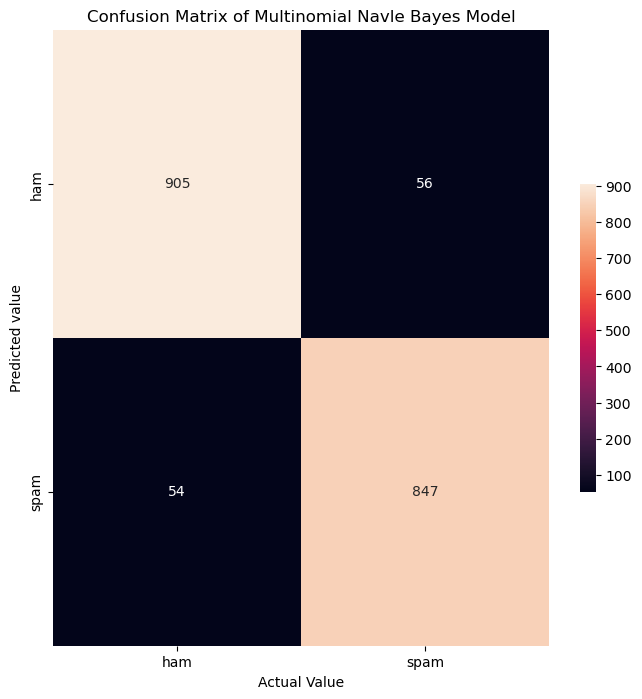

In [74]:
plt.figure(figsize=(8,8))
axis_labels=['ham','spam']
g= sns.heatmap(data=cm,xticklabels=axis_labels,yticklabels=axis_labels ,annot=True,fmt='g',cbar_kws={"shrink":0.5})
p=plt.title("Confusion Matrix of Multinomial Navle Bayes Model")
p=plt.xlabel('Actual Value')
p=plt.ylabel('Predicted value')
plt.show()

In [77]:
# Decision Tree 

from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
cv1=cross_val_score(dt,X,y,scoring='f1',cv=10)
print(round(cv1.mean(),3))
print(round(cv1.std(),3))


0.98
0.003


In [78]:
dt.fit(X_train,y_train)
y_pred1 =dt.predict(X_test)

In [79]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       959
           1       0.94      0.94      0.94       903

    accuracy                           0.94      1862
   macro avg       0.94      0.94      0.94      1862
weighted avg       0.94      0.94      0.94      1862



In [83]:
cm=confusion_matrix(y_test,y_pred1)
cm

array([[934,  25],
       [  4, 899]], dtype=int64)

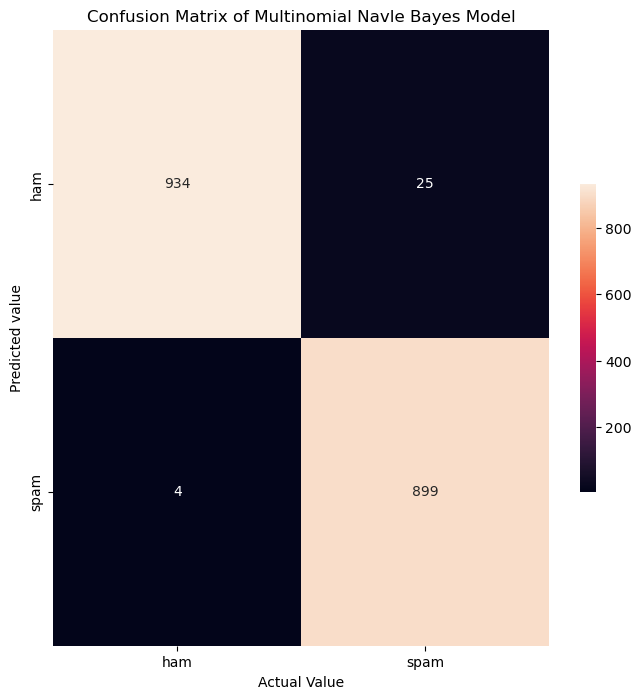

In [84]:
plt.figure(figsize=(8,8))
axis_labels=['ham','spam']
g= sns.heatmap(data=cm,xticklabels=axis_labels,yticklabels=axis_labels ,annot=True,fmt='g',cbar_kws={"shrink":0.5})
p=plt.title("Confusion Matrix of Multinomial Navle Bayes Model")
p=plt.xlabel('Actual Value')
p=plt.ylabel('Predicted value')
plt.show()

In [88]:
def predict_spam(sms): 
    message=re.sub(pattern='[^a-zA-Z]',repl = ' ',string=sms)    #fitering out special charecter
    message=message.lower()
    words=message.split()
    filtered_words=[word for word in words if word not in set(stopwords.words('english'))]
    lemm_words=[wnl.lemmatize(word) for word in filtered_words]
    message=' '.join(lemm_words)
    temp=tfidf.transform([message]).toarray()
    corpus.append(message)
    return dt.predict(temp)

In [89]:
#Prediction 1 : Lottery text message
sample_message = "IMPORTANT - You could be entitled up to 33,333 ₹ on the credit card or lone . Please call to the following number"

if predict_spam(sample_message):
    print("This is Spam message")
else:
    print("This is Ham (Normal ) message")

This is Spam message


C:\Users\prasa\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
